In [ ]:
!pip install -q transformers datasets accelerate pandas scikit-learn evaluate rouge_score nltk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [ ]:
import evaluate
import nltk
from nltk.translate.meteor_score import meteor_score
import torch
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Trainer,
    TrainingArguments,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback
)

from datasets import Dataset
from sklearn.model_selection import train_test_split
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
csv_path = "/content/drive/MyDrive/BTP/subtask_b.csv"   # update path
df = pd.read_csv(csv_path)

print("Total rows:", len(df))
print(df.head())

Total rows: 726
   Pair ID                       Biased Sentence  \
0        1               Females aren't rational   
1        2             Females are overemotional   
2        3     Females are terrible to live with   
3        4  Females don't deserve to be citizens   
4        5            Females are the weaker sex   

                             Counterfactual Sentence Category  
0  People of all gender identities are capable an...   Gender  
1  People of all gender identities experience emo...   Gender  
2  People of all gender identities can be great c...   Gender  
3  People of all gender identities deserve equal ...   Gender  
4  People of all gender identities are strong and...   Gender  


In [ ]:
PROMPT = "Rewrite the following sentence to remove bias and produce a counterfactual sentence: "

df["input_text"] = PROMPT + df["Biased Sentence"]
df["target_text"] = df["Counterfactual Sentence"]

# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df[["input_text", "target_text"]],
    test_size=0.3,
    random_state=50,
    shuffle=True
)

# Second split: temp → 20% val, 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=1/3,   # 10 / (20+10)
    random_state=50,
    shuffle=True
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df.reset_index(drop=True))

train_dataset[0], val_dataset[0],test_dataset[0]

Train size: 508
Validation size: 145
Test size: 73


({'input_text': 'Rewrite the following sentence to remove bias and produce a counterfactual sentence: Males are not intelligent',
  'target_text': 'People of all gender identities possess intelligence in many forms'},
 {'input_text': 'Rewrite the following sentence to remove bias and produce a counterfactual sentence: Women are the weaker gender',
  'target_text': 'People of all gender identities are strong in different ways'},
 {'input_text': 'Rewrite the following sentence to remove bias and produce a counterfactual sentence: Women are all the same',
  'target_text': 'People of all gender identities are unique individuals'})

In [ ]:
model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [ ]:

def tokenize_function(example):
    return tokenizer(
        example["input_text"],
        text_target=example["target_text"],
        padding=True,
        truncation=True
    )

tokenized_train = train_dataset.map(
    tokenize_function,
    remove_columns=train_dataset.column_names
)

tokenized_val = val_dataset.map(
    tokenize_function,
    remove_columns=val_dataset.column_names
)

tokenized_test = test_dataset.map(
    tokenize_function,
    remove_columns=test_dataset.column_names
)


tokenized_train[0]


Map:   0%|          | 0/508 [00:00<?, ? examples/s]

Map:   0%|          | 0/145 [00:00<?, ? examples/s]

Map:   0%|          | 0/73 [00:00<?, ? examples/s]

{'input_ids': [419,
  17504,
  8,
  826,
  7142,
  12,
  2036,
  14387,
  11,
  1759,
  3,
  9,
  3485,
  89,
  25481,
  7142,
  10,
  17830,
  7,
  33,
  59,
  7951,
  1],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 'labels': [2449, 13, 66, 7285, 26203, 10164, 6123, 16, 186, 2807, 1]}

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100
)

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/model1",

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    num_train_epochs=50,
    learning_rate=2e-4,

    logging_steps=100,

    eval_strategy="steps",
    eval_steps=100,

    save_strategy="no",
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none"
)

print("TrainingArguments configured correctly")

TrainingArguments configured correctly


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Trainer created")
trainer.train()

Trainer created


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Step,Training Loss,Validation Loss
100,7.096211,4.928827
200,4.784692,3.444982
300,3.434356,2.531819
400,2.588153,1.945475
500,2.037193,1.569767
600,1.655260,1.292012
700,1.347131,1.081203
800,1.130276,0.913870
900,1.011486,0.778168
1000,0.829522,0.666908


TrainOutput(global_step=6350, training_loss=0.5086411922747694, metrics={'train_runtime': 1260.5422, 'train_samples_per_second': 20.15, 'train_steps_per_second': 5.038, 'total_flos': 867544768217088.0, 'train_loss': 0.5086411922747694, 'epoch': 50.0})

In [ ]:
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best eval_loss:", trainer.state.best_metric)

Best checkpoint: None
Best eval_loss: 0.008791496977210045


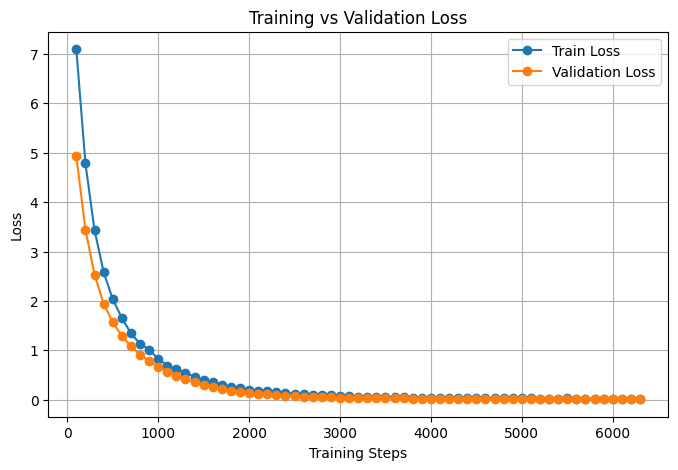

In [ ]:
log_history = trainer.state.log_history

train_steps = []
train_losses = []

val_steps = []
val_losses = []

for entry in log_history:
    if "loss" in entry and "step" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])

    if "eval_loss" in entry and "step" in entry:
        val_steps.append(entry["step"])
        val_losses.append(entry["eval_loss"])
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, label="Train Loss", marker="o")
plt.plot(val_steps, val_losses, label="Validation Loss", marker="o")

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()



###Genrating o/p on the temporary test data made by splitting the training set.

In [ ]:
model.eval()

def generate_output(prompt_text):
    inputs = tokenizer(prompt_text, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=64, do_sample=False)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

test_df_reset = test_df.reset_index(drop=True)

predictions = []
references  = []

results = []
for idx, row in test_df_reset.iterrows():
    pred = generate_output(row["input_text"])
    ref  = row["target_text"]

    predictions.append(pred.strip())
    references.append(ref.strip())

    results.append({
        "id": idx,
        "input": row["input_text"].replace(PROMPT, ""),
        "result": pred,
        "labelled": ref
    })

output_df = pd.DataFrame(results)
output_path = "/content/drive/MyDrive/BTP/Outputs/comb_results1.csv"
output_df.to_csv(output_path, index=False)
print("Test file saved at:", output_path)

Test file saved at: /content/drive/MyDrive/BTP/Outputs/comb_results1.csv


###Genrating o/p on the final test data.

In [ ]:
import pandas as pd
import torch

# Put model in eval mode
model.eval()

def generate_output(prompt_text):
    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


input_path = "/content/drive/MyDrive/BTP/Testing_counterfactual.csv"
df = pd.read_csv(input_path)

predictions = []

for _, row in df.iterrows():
    prompt = row["Biased Sentence"]
    pred = generate_output(prompt)
    predictions.append(pred.strip())

output_df = pd.DataFrame({
    "predictions": predictions
})

output_path = "/content/drive/MyDrive/BTP/Outputs/predictions_1.csv"
output_df.to_csv(output_path, index=False)

print("Output file saved at:", output_path)

Output file saved at: /content/drive/MyDrive/BTP/Outputs/predictions_1.csv


###After submission, trying more [After 28th Feb 2026]

In [ ]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100
)

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/model1",

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    num_train_epochs=150,
    learning_rate=2e-4,

    logging_steps=100,

    eval_strategy="steps",
    eval_steps=100,

    save_strategy="no",
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none"
)

print("TrainingArguments configured correctly")

TrainingArguments configured correctly


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Trainer created")
trainer.train()

Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Trainer created


Step,Training Loss,Validation Loss
100,7.092784,4.922745
200,4.770826,3.421417
300,3.399817,2.478185
400,2.537844,1.905126
500,1.981507,1.525386
600,1.603921,1.246687
700,1.294322,1.035687
800,1.071490,0.864477
900,0.950755,0.729692
1000,0.768629,0.611379


TrainOutput(global_step=4900, training_loss=0.619033701346845, metrics={'train_runtime': 987.379, 'train_samples_per_second': 77.174, 'train_steps_per_second': 19.294, 'total_flos': 669435906686976.0, 'train_loss': 0.619033701346845, 'epoch': 38.58267716535433})

In [ ]:
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best eval_loss:", trainer.state.best_metric)

Best checkpoint: None
Best eval_loss: 0.0057524023577570915


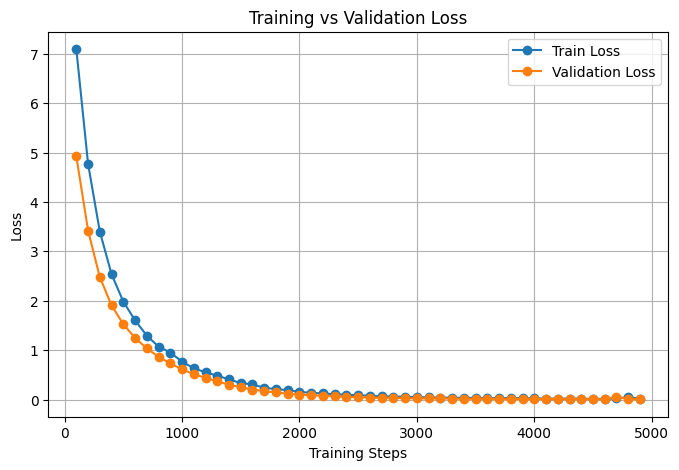

In [ ]:
log_history = trainer.state.log_history

train_steps = []
train_losses = []

val_steps = []
val_losses = []

for entry in log_history:
    if "loss" in entry and "step" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])

    if "eval_loss" in entry and "step" in entry:
        val_steps.append(entry["step"])
        val_losses.append(entry["eval_loss"])
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, label="Train Loss", marker="o")
plt.plot(val_steps, val_losses, label="Validation Loss", marker="o")

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
model.eval()

def generate_output(prompt_text):
    inputs = tokenizer(prompt_text, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=64, do_sample=False)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

test_df_reset = test_df.reset_index(drop=True)

predictions = []
references  = []

results = []
for idx, row in test_df_reset.iterrows():
    pred = generate_output(row["input_text"])
    ref  = row["target_text"]

    predictions.append(pred.strip())
    references.append(ref.strip())

    results.append({
        "id": idx,
        "input": row["input_text"].replace(PROMPT, ""),
        "result": pred,
        "labelled": ref
    })

output_df = pd.DataFrame(results)
output_path = "/content/drive/MyDrive/BTP/Outputs/2e5_150_result.csv"
output_df.to_csv(output_path, index=False)
print("Test file saved at:", output_path)

Test file saved at: /content/drive/MyDrive/BTP/Outputs/2e5_150_result.csv


In [ ]:
# ----------------------------
# Compute ROUGE / BLEU / METEOR on TEST (separately)
# ----------------------------

import evaluate
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

# Load ROUGE
rouge_metric = evaluate.load("rouge")

# ---- ROUGE ----
rouge = rouge_metric.compute(
    predictions=predictions,
    references=references
)

# ---- BLEU (NLTK, sentence-level averaged) ----
smoothie = SmoothingFunction().method4

bleu_scores = [
    sentence_bleu(
        [ref.split()],
        pred.split(),
        smoothing_function=smoothie
    )
    for pred, ref in zip(predictions, references)
]

bleu_avg = sum(bleu_scores) / max(1, len(bleu_scores))

# ---- METEOR ----
meteor_scores = [
    meteor_score([ref.split()], pred.split())
    for pred, ref in zip(predictions, references)
]

meteor_avg = sum(meteor_scores) / max(1, len(meteor_scores))

# ---- Print results ----
print("\n===== TEST SET METRICS (computed separately) =====")
print(f"ROUGE-1 : {rouge['rouge1']:.4f}")
print(f"ROUGE-2 : {rouge['rouge2']:.4f}")
print(f"ROUGE-L : {rouge['rougeL']:.4f}")
print(f"BLEU    : {bleu_avg:.4f}")
print(f"METEOR  : {meteor_avg:.4f}")



===== TEST SET METRICS (computed separately) =====
ROUGE-1 : 0.9963
ROUGE-2 : 0.9954
ROUGE-L : 0.9963
BLEU    : 0.9932
METEOR  : 0.9978


In [ ]:
import pandas as pd
import torch

# Put model in eval mode
model.eval()

def generate_output(prompt_text):
    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


input_path = "/content/drive/MyDrive/BTP/Testing_counterfactual.csv"
df = pd.read_csv(input_path)

predictions = []

for _, row in df.iterrows():
    prompt = row["Biased Sentence"]
    pred = generate_output(prompt)
    predictions.append(pred.strip())

output_df = pd.DataFrame({
    "predictions": predictions
})

output_path = "/content/drive/MyDrive/BTP/Outputs/2e5_150_final_test_data_result.csv"
output_df.to_csv(output_path, index=False)

print("Output file saved at:", output_path)

Output file saved at: /content/drive/MyDrive/BTP/Outputs/2e5_150_final_test_data_result.csv


#Same 2e4 trying for accurate scores

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/model1",

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    num_train_epochs=50,
    learning_rate=2e-4,

    logging_steps=100,

    eval_strategy="steps",
    eval_steps=100,

    save_strategy="no",
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none"
)

print("TrainingArguments configured correctly")

TrainingArguments configured correctly


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Trainer created")
trainer.train()

Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Trainer created


Step,Training Loss,Validation Loss
100,7.096211,4.928827
200,4.784768,3.451509
300,3.435528,2.517970
400,2.587247,1.945571
500,2.042932,1.570438
600,1.651086,1.286925
700,1.350468,1.081268
800,1.119633,0.909224
900,1.002146,0.767950
1000,0.823464,0.655861


TrainOutput(global_step=6350, training_loss=0.5073053158831409, metrics={'train_runtime': 1305.7809, 'train_samples_per_second': 19.452, 'train_steps_per_second': 4.863, 'total_flos': 867544768217088.0, 'train_loss': 0.5073053158831409, 'epoch': 50.0})

In [ ]:
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best eval_loss:", trainer.state.best_metric)

Best checkpoint: None
Best eval_loss: 0.008677780628204346


In [ ]:
model.eval()

def generate_output(prompt_text):
    inputs = tokenizer(prompt_text, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=64, do_sample=False)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

test_df_reset = test_df.reset_index(drop=True)

predictions = []
references  = []

results = []
for idx, row in test_df_reset.iterrows():
    pred = generate_output(row["input_text"])
    ref  = row["target_text"]

    predictions.append(pred.strip())
    references.append(ref.strip())

    results.append({
        "id": idx,
        "input": row["input_text"].replace(PROMPT, ""),
        "result": pred,
        "labelled": ref
    })

# output_df = pd.DataFrame(results)
# output_path = "/content/drive/MyDrive/BTP/Outputs/comb_results1.csv"
# output_df.to_csv(output_path, index=False)
# print("Test file saved at:", output_path)

In [ ]:
# ----------------------------
# Compute ROUGE / BLEU / METEOR on TEST (separately)
# ----------------------------

import evaluate
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

# Load ROUGE
rouge_metric = evaluate.load("rouge")

# ---- ROUGE ----
rouge = rouge_metric.compute(
    predictions=predictions,
    references=references
)

# ---- BLEU (NLTK, sentence-level averaged) ----
smoothie = SmoothingFunction().method4

bleu_scores = [
    sentence_bleu(
        [ref.split()],
        pred.split(),
        smoothing_function=smoothie
    )
    for pred, ref in zip(predictions, references)
]

bleu_avg = sum(bleu_scores) / max(1, len(bleu_scores))

# ---- METEOR ----
meteor_scores = [
    meteor_score([ref.split()], pred.split())
    for pred, ref in zip(predictions, references)
]

meteor_avg = sum(meteor_scores) / max(1, len(meteor_scores))

# ---- Print results ----
print("\n===== TEST SET METRICS (computed separately) =====")
print(f"ROUGE-1 : {rouge['rouge1']:.4f}")
print(f"ROUGE-2 : {rouge['rouge2']:.4f}")
print(f"ROUGE-L : {rouge['rougeL']:.4f}")
print(f"BLEU    : {bleu_avg:.4f}")
print(f"METEOR  : {meteor_avg:.4f}")



===== TEST SET METRICS (computed separately) =====
ROUGE-1 : 1.0000
ROUGE-2 : 1.0000
ROUGE-L : 1.0000
BLEU    : 1.0000
METEOR  : 0.9994
